What we are going to do?
Analysis-->Feature Engineering-->model-->web app

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)



In [3]:
sns.set_style('whitegrid')

In [4]:
df=pd.read_csv('german_credit_data.csv')

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [7]:
df.shape

(1000, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df["Job"].unique()

array([2, 1, 3, 0])

In [11]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Saving accounts"] = df["Saving accounts"].fillna("none")
df["Checking account"] = df["Checking account"].fillna("none")

In [14]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,none,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,none,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,none,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,none,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [15]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [16]:
df.drop(columns='Unnamed: 0', inplace=True)

In [17]:
df.columns


Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

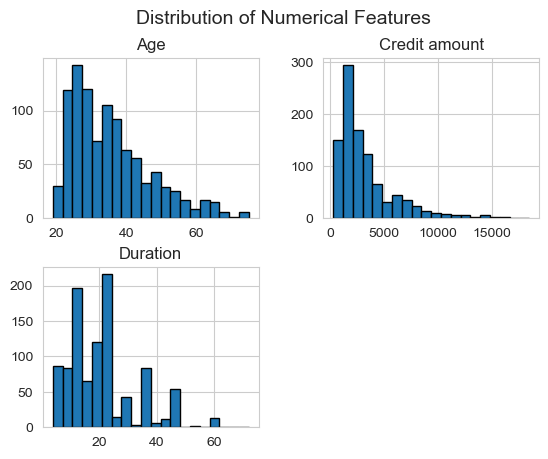

In [18]:
df[["Age","Credit amount","Duration"]].hist(bins=20,edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

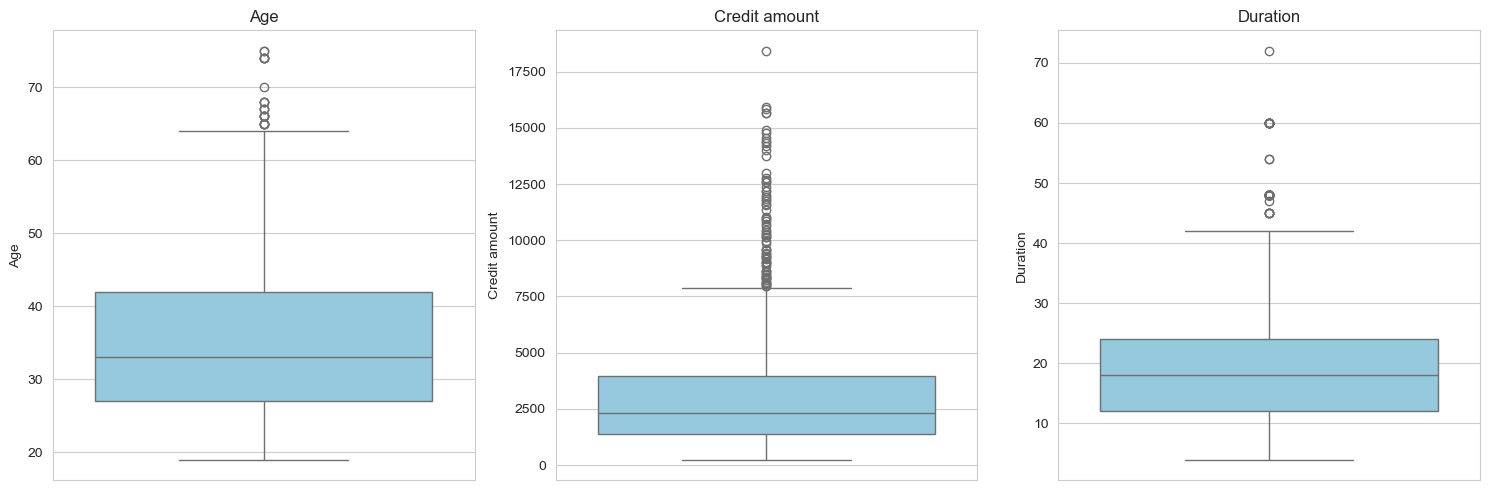

In [19]:
plt.figure(figsize=(15,5))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()    

In [20]:
df.query("Duration>=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,none,10144,60,radio/TV,good
255,27,male,1,own,none,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,none,none,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,none,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,none,15653,60,radio/TV,good
672,42,male,3,own,little,none,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [21]:
categorical_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

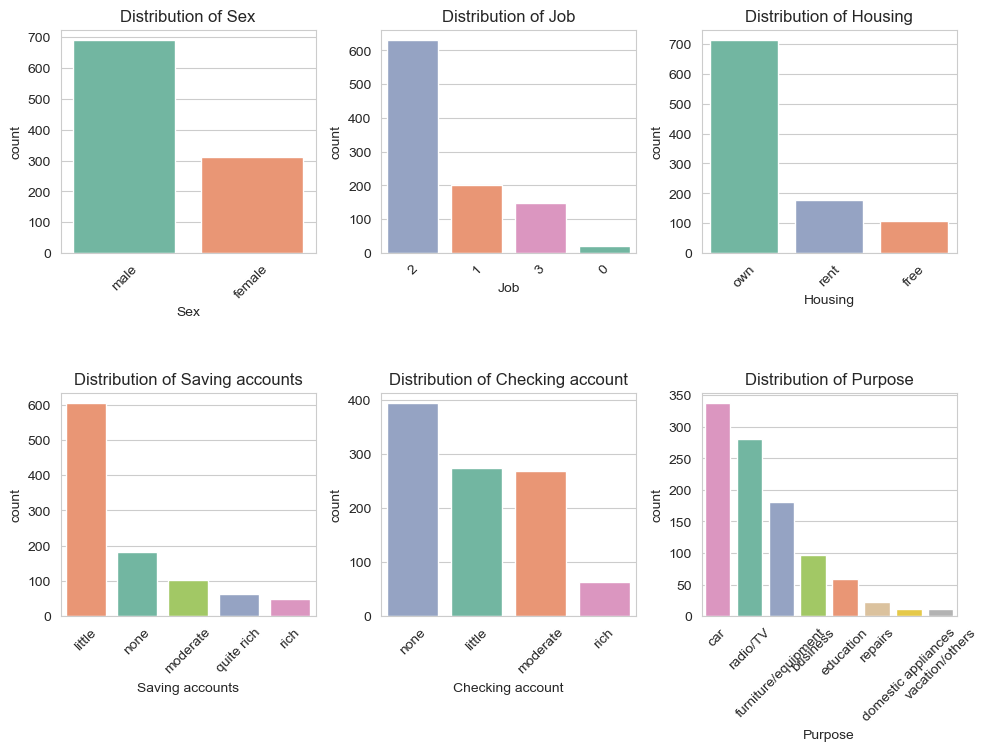

In [22]:
plt.figure(figsize=(10,10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette="Set2",
        order=df[col].value_counts().index,
        legend=False
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
corr=df[["Age","Job","Credit amount","Duration"]].corr()

In [24]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


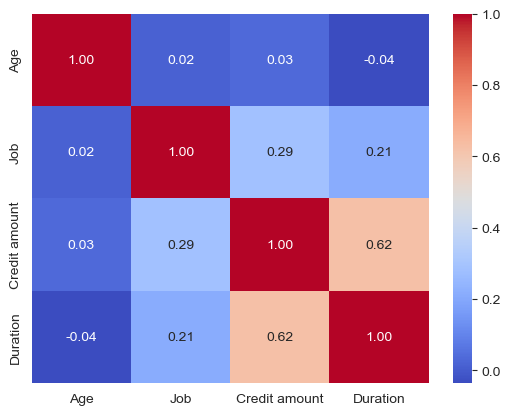

In [25]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [26]:
df.groupby("Job")[["Credit amount"]].mean()

,Credit amount
Job,
0,2745.136364
1,2358.520000
2,3070.965079
3,5435.493243


In [27]:
df.groupby("Sex")[["Credit amount"]].mean()

,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [28]:
pd.pivot_table(df, index="Housing", columns="Purpose", values="Credit amount")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


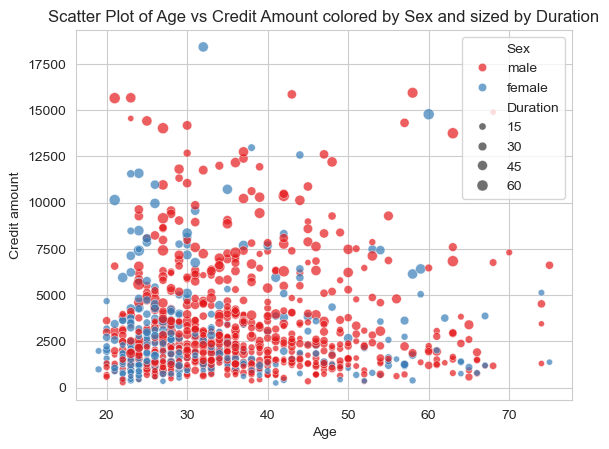

In [29]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex",size="Duration",alpha=0.7,palette="Set1")
plt.title("Scatter Plot of Age vs Credit Amount colored by Sex and sized by Duration")
plt.show()

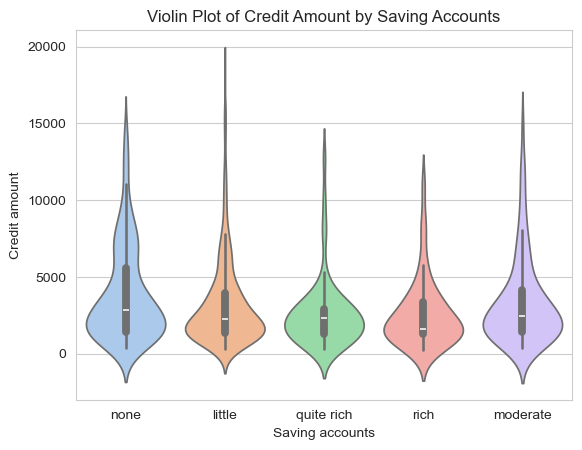

In [30]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="pastel",hue="Saving accounts")
plt.title("Violin Plot of Credit Amount by Saving Accounts")
plt.show()

In [31]:
df["Risk"].value_counts(normalize=True)*100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

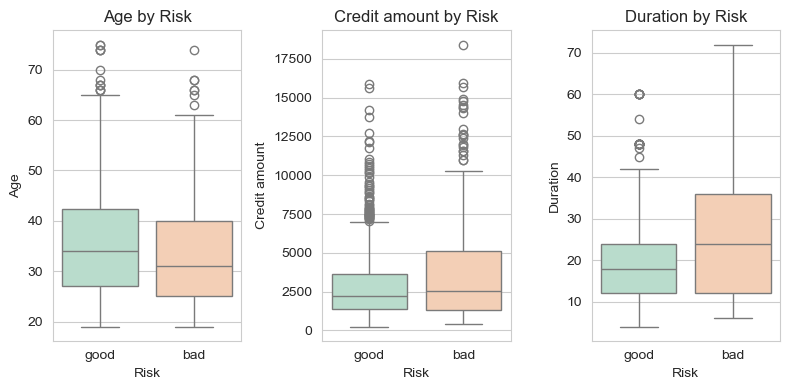

In [32]:
plt.figure(figsize=(8,4))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x="Risk",y=col,hue="Risk",palette="Pastel2")
    plt.title(f"{col} by Risk")
plt.tight_layout()
plt.show()

In [33]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


In [34]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

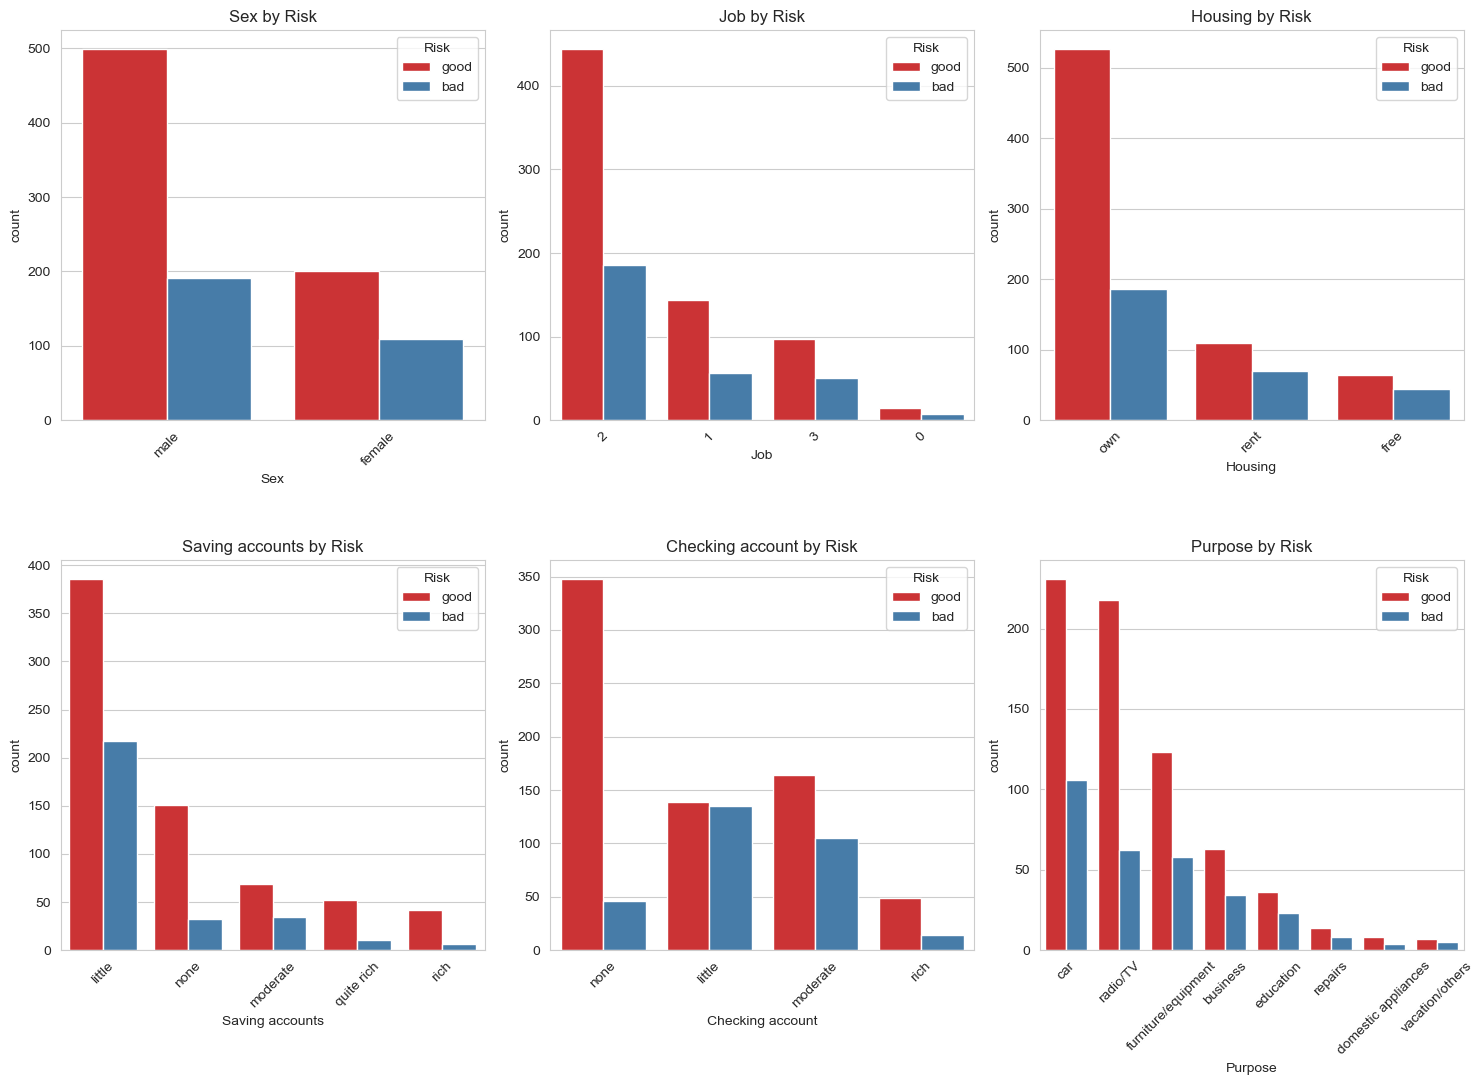

In [35]:
plt.figure(figsize=(15,15))
for i,col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df,x=col,hue="Risk",palette="Set1",order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
df.columns


Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [37]:
features=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [38]:
target="Risk"

In [39]:
df_model=df[features+[target]].copy()

In [40]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,male,2,own,none,little,1169,6,good
1,22,female,2,own,little,moderate,5951,48,bad
2,49,male,1,own,little,none,2096,12,good
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad


In [41]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [42]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")


In [43]:
le_dict={}

In [44]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [45]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le,f"{col}_label_encoder.pkl")

In [46]:
le_target=LabelEncoder()

In [47]:
target

'Risk'

In [48]:
df_model[target]=le_target.fit_transform(df_model[target])

In [49]:
df_model[target].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [50]:
joblib.dump(le_target,"target_encoder.pkl")

['target_encoder.pkl']

In [51]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,1,2,1,2,0,1169,6,1
1,22,0,2,1,0,1,5951,48,0
2,49,1,1,1,0,2,2096,12,1
3,45,1,2,0,0,0,7882,42,1
4,53,1,2,0,0,0,4870,24,0


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X=df_model.drop(target, axis=1)

In [54]:
Y=df_model[target]

In [55]:
df["Saving accounts"].unique()

array(['none', 'little', 'quite rich', 'rich', 'moderate'], dtype=object)

In [56]:
df["Checking account"].unique()

array(['little', 'moderate', 'none', 'rich'], dtype=object)

In [57]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,67,1,2,1,2,0,1169,6
1,22,0,2,1,0,1,5951,48
2,49,1,1,1,0,2,2096,12
3,45,1,2,0,0,0,7882,42
4,53,1,2,0,0,0,4870,24
...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,2,1736,12
996,40,1,3,1,0,0,3857,30
997,38,1,2,1,0,2,804,12
998,23,1,2,0,0,0,1845,45


In [58]:
Y

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=1, stratify=Y)

In [60]:
X_train.shape

(800, 8)

In [61]:
X_test.shape

(200, 8)

In [62]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [64]:
def train_model(model,param_grid,X_train,Y_train,X_test,Y_test):
    grid=GridSearchCV(model,param_grid=param_grid,cv=5,n_jobs=-1,scoring="accuracy")
    grid.fit(X_train,Y_train)
    best_model=grid.best_estimator_
    Y_pred=best_model.predict(X_test)
    acc=accuracy_score(Y_test,Y_pred)
    return best_model,acc, grid.best_params_



In [65]:
dt=DecisionTreeClassifier(random_state=1,class_weight="balanced")
dt_param_grid={
    "max_depth": [3, 5, 7,10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [66]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, Y_train, X_test, Y_test)

In [67]:
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.705


In [68]:
print("Best parameters",params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [69]:
rf=RandomForestClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [70]:
rf_param_grid={
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

In [71]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, Y_train, X_test, Y_test)

In [72]:
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.765


In [73]:
print("Best params",params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [74]:
et=ExtraTreesClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [75]:
et_param_grid={
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10,None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

In [76]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, Y_train, X_test, Y_test)

In [77]:
print("Extra Trees Accuracy:", acc_et)

Extra Trees Accuracy: 0.745


In [78]:
print("Best params",params_et)

Best params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [79]:
xgb=XGBClassifier(random_state=1,scale_pos_weight=(Y_train==0).sum()/(Y_train==1).sum(),use_label_encoder=False,eval_metric='logloss')

In [80]:
xgb_param_grid={
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]}

In [81]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, Y_train, X_test, Y_test)

c:\Users\AKSHIT\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:18:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [82]:
print("XGB Accuracy:", acc_xgb)

XGB Accuracy: 0.73


In [83]:
print("Best Params:",params_xgb)

Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


In [84]:
best_et.predict(X_test)

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0])

In [86]:
joblib.dump(best_rf, "random_forest_credit_model.pkl")

['random_forest_credit_model.pkl']